In [394]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
import pandas as pd
import os
import geopandas as gpd
import pyproj
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
import requests

import geopandas as gpd
import pandas as pd
import requests
from shapely.geometry import Point
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.geometry import box

In [206]:
# Load clean_dfs from the file
with open('clean_dfs.pkl', 'rb') as f:
    clean_dfs_loaded = pickle.load(f)

print("✅ clean_dfs loaded successfully!")

well_data = clean_dfs_loaded

✅ clean_dfs loaded successfully!


In [207]:
# To check the contents, you can print the keys or preview one of the DataFrames
print(clean_dfs_loaded.keys())  # Shows the keys (names of DataFrames in the dictionary)

# For example, to preview the first DataFrame in the dictionary
clean_dfs_loaded['WQD_21_Blaine_Crosby_Deep.xlsx'].head()

dict_keys(['WQD_21_Blaine_Crosby_Deep.xlsx', 'WQD_09_Great_Western_Shallow.xlsx', 'WQD_25_Hellgate_Monument.xlsx', 'WQD_32_South_Bancroft.xlsx', 'WQD_24_Vantage_Villa.xlsx', 'WQD_27_Deer_Creek_Rd.xlsx', 'WQD_28_Vine_Jackson.xlsx', 'Thunderbolt_Monitoring.xlsx', 'WQD_29_Madison_Street.xlsx', 'WQD_36_Spurgin_Kelly.xlsx', 'MMW_4_Whipporwill.xlsx', 'WQD_22_Great_Western_Deep.xlsx', 'WQD_35_Buckhouse_Bridge.xlsx', 'WQD_43_Travelers_Rest.xlsx', 'WQD_18_Glacier_Drive.xlsx', 'WQD_23_Lincolnwood.xlsx', 'WQD_11_Alvina_Park.xlsx', 'MMW_3_Airport.xlsx', 'WQD_31_Blaine_Crosby_Shallow.xlsx', 'WQD_19_Miller_Creek_Road.xlsx', 'WQD_12_Michael_Lane.xlsx', 'MMW_8_Broadway.xlsx', 'WQD_30_McCormick_Park.xlsx', 'WQD_08 C.S Porter.xlsx', 'Thunderbolt_Domestic.xlsx'])


,Water_TempC,Date_Time,Raw_WL_ft,Logger_issue,Well_Name,GWIC_ID,PVC_Elev,Perf_Upper,Perf_Lower,Total_Depth,Discontinued,Longitude,Latitude,Water_Level_Elevation
0,NaN,2023-09-26 11:39:00,64.4300,0.002,WQD_21,157208,3204.100098,113.0,118.0,118.0,NO,-107.767663,8.895416,3139.670098
1,9.007222,2023-09-26 13:05:26,64.4320,NaN,WQD_21,157208,3204.100098,113.0,118.0,118.0,NO,-107.767663,8.895416,3139.668098
2,9.012778,2023-09-26 14:05:26,64.4778,NaN,WQD_21,157208,3204.100098,113.0,118.0,118.0,NO,-107.767663,8.895416,3139.622298
3,9.011111,2023-09-26 15:05:26,64.5028,NaN,WQD_21,157208,3204.100098,113.0,118.0,118.0,NO,-107.767663,8.895416,3139.597298
4,9.011111,2023-09-26 16:05:26,64.5027,NaN,WQD_21,157208,3204.100098,113.0,118.0,118.0,NO,-107.767663,8.895416,3139.597398


WQD_21_Blaine_Crosby_Deep.xlsx: ['water_tempc', 'date_time', 'raw_wl_ft', 'logger_issue', 'well_name', 'gwic_id', 'pvc_elev', 'perf_upper', 'perf_lower', 'total_depth', 'discontinued', 'longitude', 'latitude', 'water_level_elevation']
WQD_09_Great_Western_Shallow.xlsx: ['water_tempc', 'date_time', 'raw_wl_ft', 'logger_issue', 'well_name', 'gwic_id', 'pvc_elev', 'perf_upper', 'perf_lower', 'total_depth', 'discontinued', 'longitude', 'latitude', 'water_level_elevation']
WQD_25_Hellgate_Monument.xlsx: ['water_tempc', 'date_time', 'raw_wl_ft', 'logger_issue', 'well_name', 'gwic_id', 'pvc_elev', 'perf_upper', 'perf_lower', 'total_depth', 'discontinued', 'longitude', 'latitude', 'water_level_elevation']
WQD_32_South_Bancroft.xlsx: ['water_tempc', 'date_time', 'raw_wl_ft', 'logger_issue', 'well_name', 'gwic_id', 'pvc_elev', 'perf_upper', 'perf_lower', 'total_depth', 'discontinued', 'longitude', 'latitude', 'water_level_elevation']
WQD_24_Vantage_Villa.xlsx: ['water_tempc', 'date_time', 'raw_w

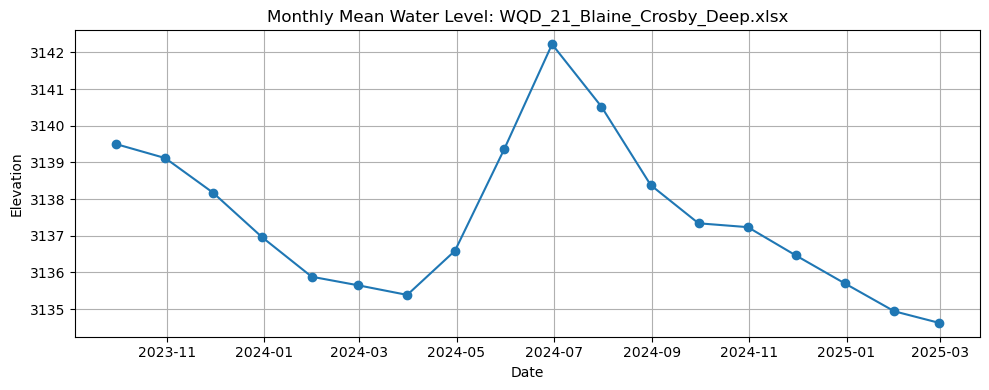

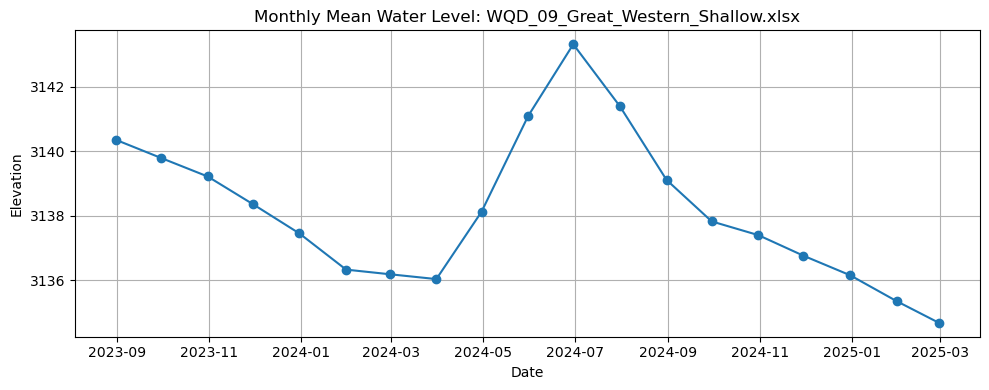

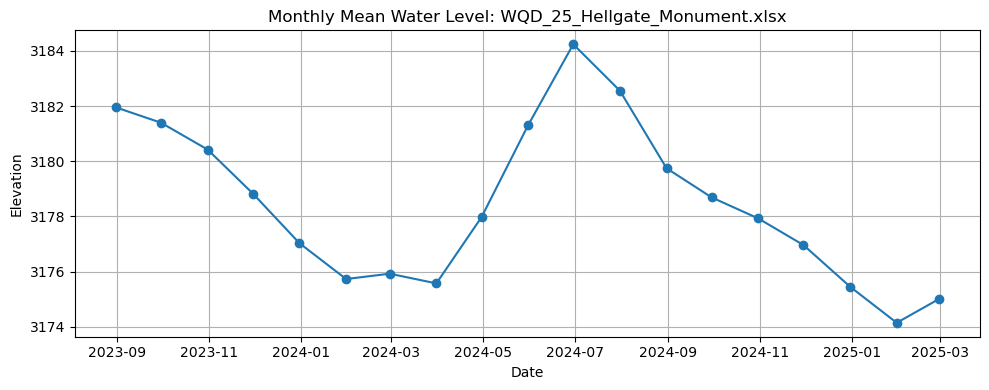

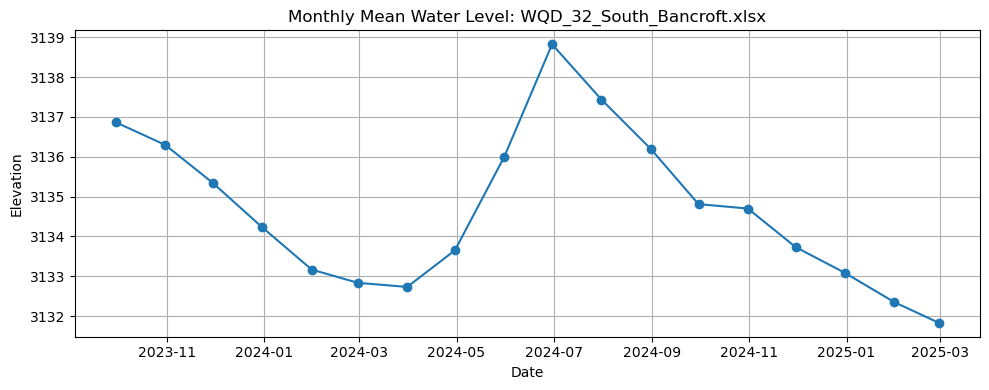

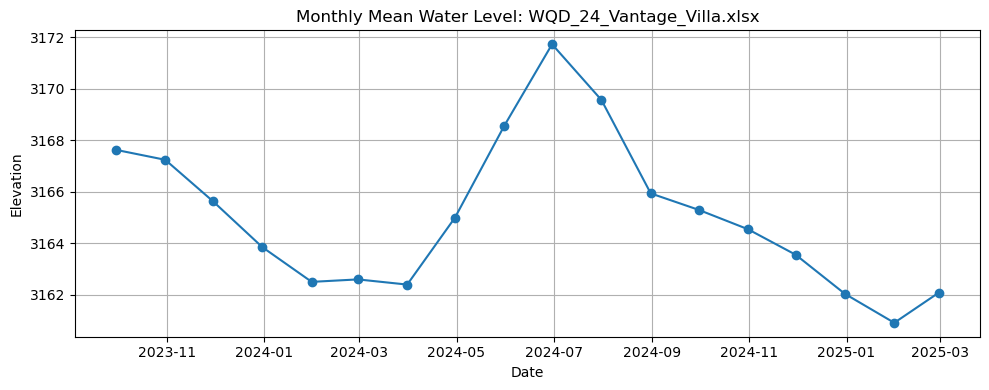

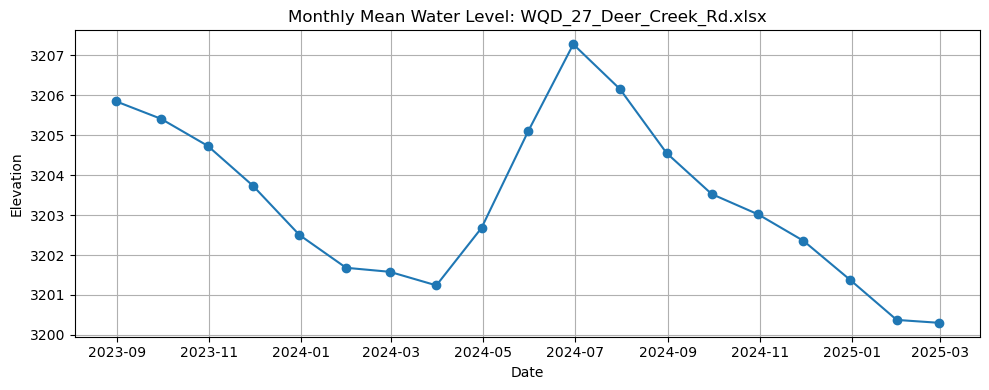

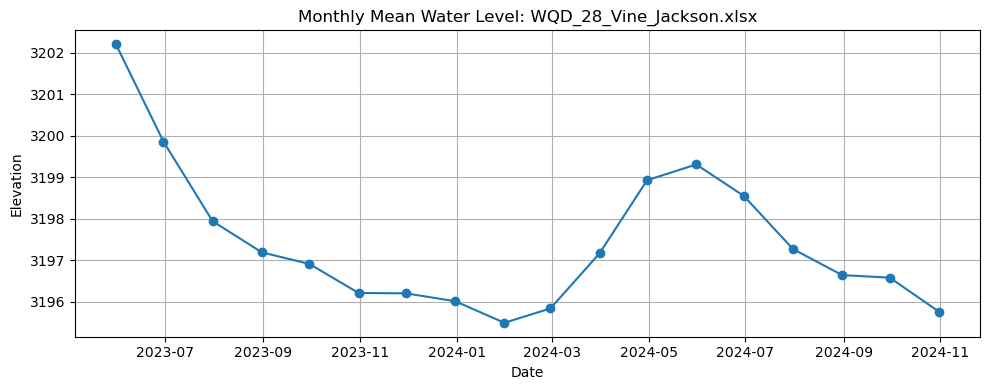

⚠️ Skipping Thunderbolt_Monitoring.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']


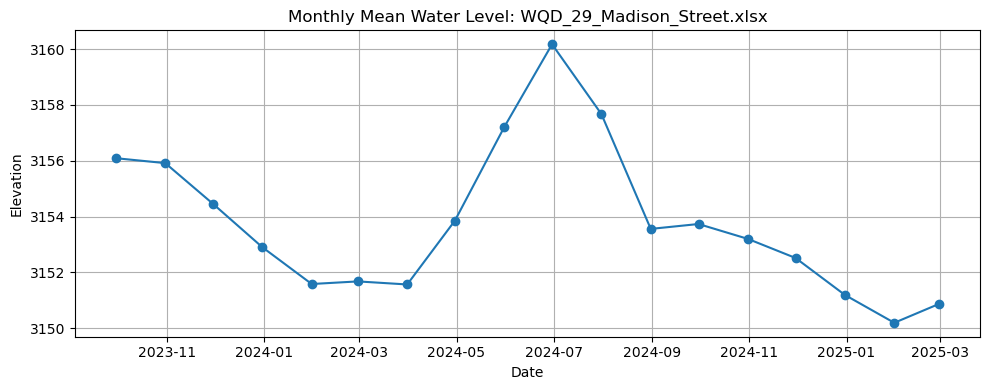

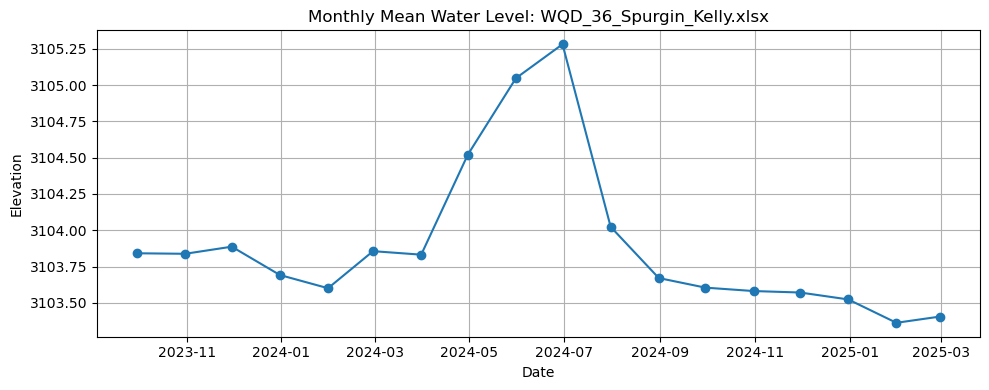

⚠️ Skipping MMW_4_Whipporwill.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']


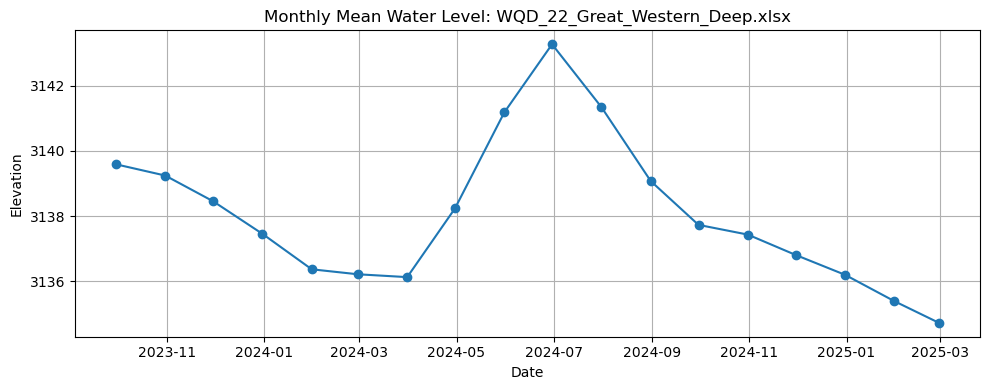

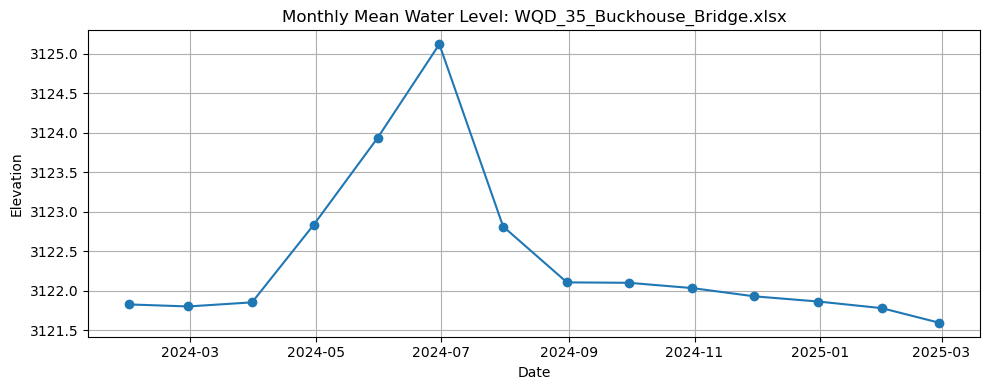

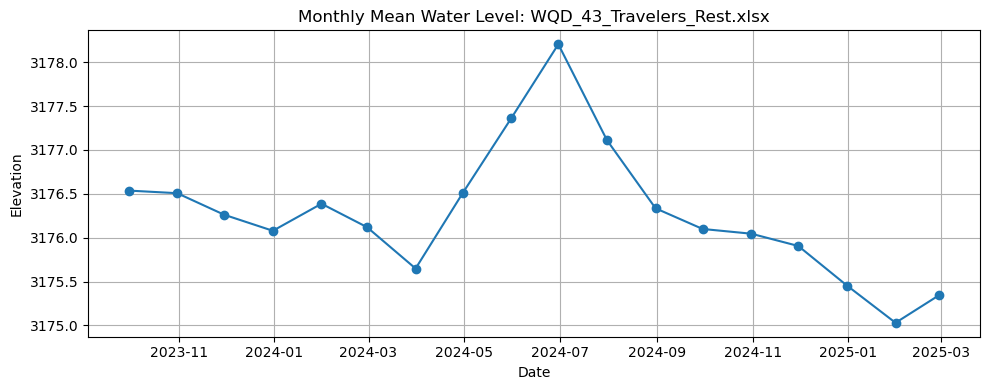

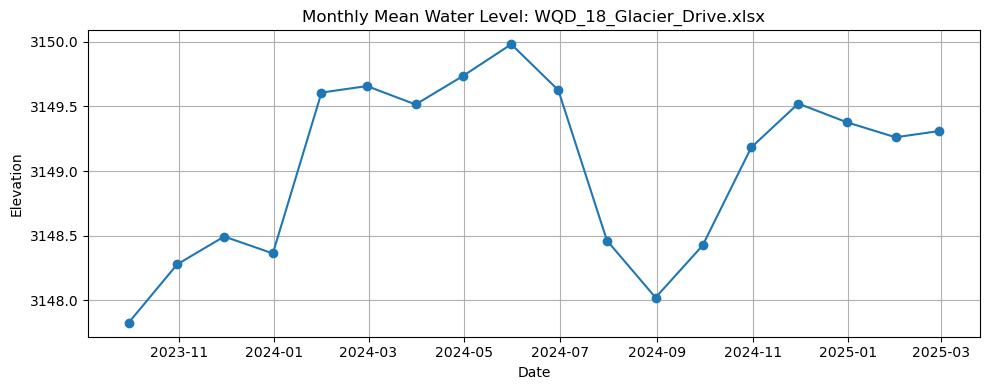

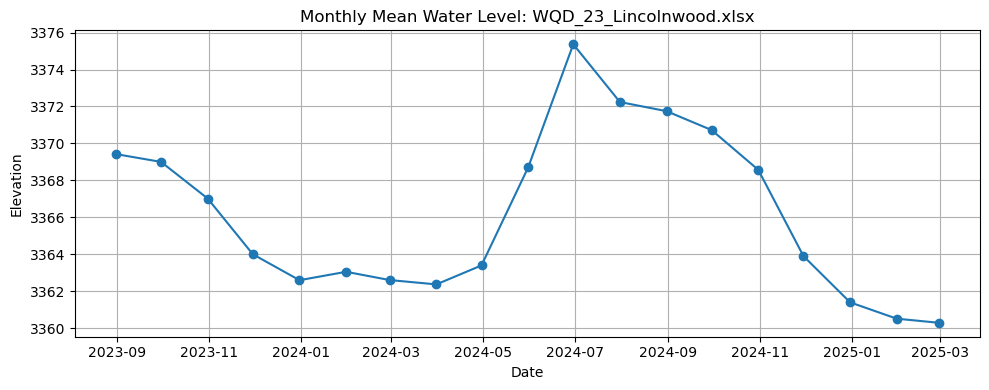

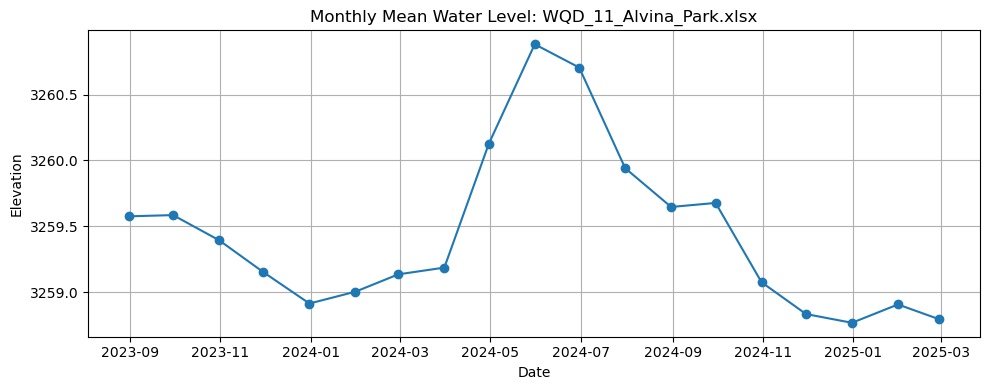

⚠️ Skipping MMW_3_Airport.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']


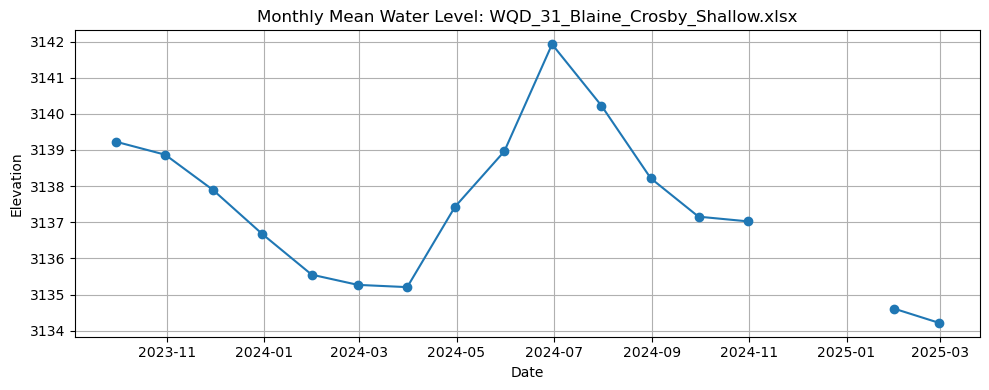

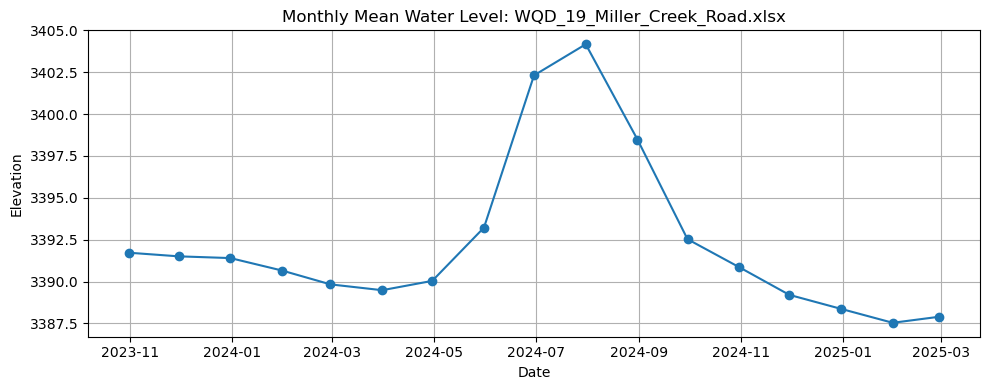

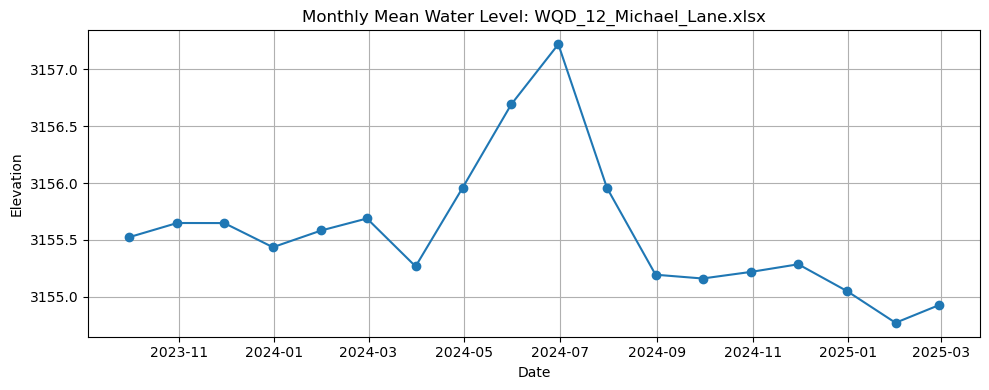

⚠️ Skipping MMW_8_Broadway.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']


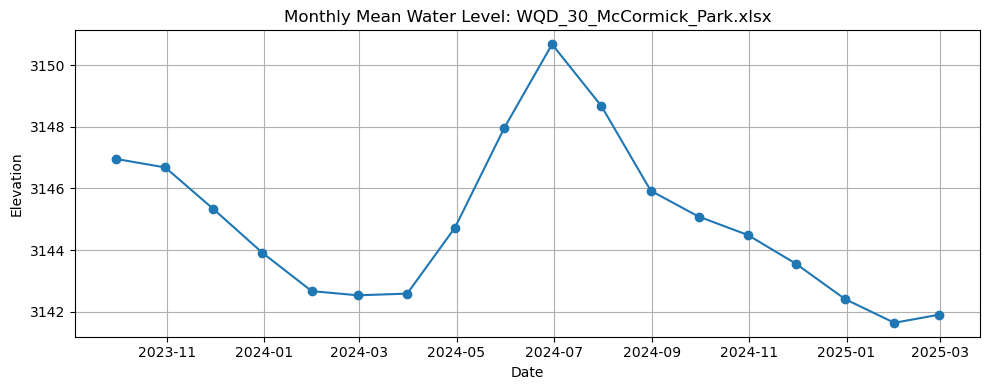

⚠️ Skipping WQD_08 C.S Porter.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']
⚠️ Skipping Thunderbolt_Domestic.xlsx: missing ['water_level_elevation', 'latitude', 'longitude']


In [397]:
# 0. (Optional) Look at your raw column names:
for well_name, df in well_data.items():
    print(f"{well_name}: {list(df.columns)}")

# 1. Normalize all column names to lowercase/underscores
for well_name, df in well_data.items():
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )
    well_data[well_name] = df

# 2. Prepare output folder
output_dir = "monthly_well_data"
os.makedirs(output_dir, exist_ok=True)

monthly_dfs = {}

# 3. Loop through wells
for well_name, df in well_data.items():
    df = df.copy()

    # 3a. Check required columns
    req = ['date_time', 'water_level_elevation', 'latitude', 'longitude']
    missing = [c for c in req if c not in df.columns]
    if missing:
        print(f"⚠️ Skipping {well_name}: missing {missing}")
        continue

    # 3b. DateTime → index
    df['date_time'] = pd.to_datetime(df['date_time'])
    df.set_index('date_time', inplace=True)

    # 3c. Resample to month‑end mean (use 'ME' alias)
    monthly_mean = df['water_level_elevation'].resample('ME').mean()

    # 3d. Extract constant lat/lon
    lat = df['latitude'].iloc[0]
    lon = df['longitude'].iloc[0]

    # 3e. Build tidy DataFrame
    monthly_df = monthly_mean.to_frame(name='water_level_elevation_mean')
    monthly_df['latitude'] = lat
    monthly_df['longitude'] = lon
    monthly_df = monthly_df.reset_index()

    monthly_dfs[well_name] = monthly_df
    
    # 3f. Save CSV
    csv_path = os.path.join(output_dir, f"{well_name}_monthly.csv")
    monthly_df.to_csv(csv_path, index=False)
  #  print(f"→ Saved {csv_path}")

    # 3g. Plot
    plt.figure(figsize=(10, 4))
    plt.plot(monthly_df['date_time'], monthly_df['water_level_elevation_mean'], marker='o')
    plt.title(f"Monthly Mean Water Level: {well_name}")
    plt.xlabel("Date")
    plt.ylabel("Elevation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [209]:
monthly_dfs = {
    (k[:-5] if k.endswith('.xlsx') else k): df
    for k, df in monthly_dfs.items()
}

In [210]:
# Reprojecting to get UMTS for Kriging
for name, df in monthly_dfs.items():
    # Step 1: Convert to GeoDataFrame with WGS84 CRS
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs="EPSG:4326"  # geographic coordinates
    )

    # Step 2: Reproject to UTM Zone 12N
    gdf_utm = gdf.to_crs("EPSG:32612")

    # Step 3: Add UTM coordinates to DataFrame
    df['x_utm'] = gdf_utm.geometry.x
    df['y_utm'] = gdf_utm.geometry.y

    # Save back into the dictionary
    monthly_dfs[name] = df


In [401]:
# Reformat dictionary of dfs to one df and streamline indexing (multiindex: by monthand year, and by well)
wells_month_df = (
    pd.concat(monthly_dfs.values(), keys=monthly_dfs.keys(), names=['well', 'row'])
    .reset_index(level='row', drop=True)
    .reset_index()
    .assign(
        date_time=lambda x: pd.to_datetime(x['date_time']),  # Convert 'date_time' column
        year_month=lambda x: x['date_time'].dt.to_period('M')  # Extract Year-Month
    )
    .drop('date_time', axis=1)  # Drop the 'date_time' column
    .set_index('year_month')  # Set 'year_month' as the index
)

wells_month_df['Well_ID'] = wells_month_df['well'].str.split('_').str[:2].str.join('_').str.replace('_', '-')



In [418]:
wells_month_df = (
    pd.concat(monthly_dfs.values(), keys=monthly_dfs.keys(), names=['well', 'row'])
    .reset_index(level='row', drop=True)
    .reset_index()  # Keep 'well' as a column instead of making it part of the index
    .assign(
        date_time=lambda x: pd.to_datetime(x['date_time']),  # Convert 'date_time' column
        year_month=lambda x: x['date_time'].dt.to_period('M')  # Extract Year-Month
    )
    .drop('date_time', axis=1)  # Drop the 'date_time' column
)

# Now you can use 'well' and 'year_month' as regular columns
wells_month_df['Well_ID'] = wells_month_df['well'].str.split('_').str[:2].str.join('_').str.replace('_', '-')

# Check the result
wells_month_df.head()

,well,water_level_elevation_mean,latitude,longitude,year_month,Well_ID
0,WQD_21_Blaine_Crosby_Deep.xlsx,3139.501571,8.895416,-107.767663,2023-09,WQD-21
1,WQD_21_Blaine_Crosby_Deep.xlsx,3139.118008,8.895416,-107.767663,2023-10,WQD-21
2,WQD_21_Blaine_Crosby_Deep.xlsx,3138.174362,8.895416,-107.767663,2023-11,WQD-21
3,WQD_21_Blaine_Crosby_Deep.xlsx,3136.953026,8.895416,-107.767663,2023-12,WQD-21
4,WQD_21_Blaine_Crosby_Deep.xlsx,3135.881301,8.895416,-107.767663,2024-01,WQD-21


In [419]:
# 1. Load the wells shapefile
wells_shp = gpd.read_file("WQD_Monitoring_Wells.shp")

# 2. Reproject to lat/lon
wells_latlon = wells_shp.to_crs(epsg=4326)

# 3. Merge with wells_latlon to add lat/lon geometries
wells_month_df = wells_month_df.merge(wells_latlon[['Well_ID', 'geometry']], on='Well_ID', how='left')

# 4. Convert wells_month_df to a GeoDataFrame
wells_month_df = gpd.GeoDataFrame(wells_month_df, geometry='geometry', crs='EPSG:4326')


In [423]:
# Drop the 'geometry_y' column

#wells_month_df = wells_month_df.drop(columns=['geometry_y'])

# Check the updated DataFrame
wells_month_df.head()
wells_month_df = wells_month_df.reset_index()
wells_month_df.to_csv('wells_month.csv', index=False)

In [416]:
wells_month_df = wells_month_df.reset_index()

# Extract latitude and longitude from the 'geometry' column
wells_month_df['longitude'] = wells_gdf.geometry.x
wells_month_df['latitude'] = wells_gdf.geometry.y

# Check the updated DataFrame
wells_month_df.head()

ValueError: cannot reindex on an axis with duplicate labels

In [408]:
wells_month_df.to_csv('wells_month.csv', index=False)
wells_month_df.to_file('wells_month.shp')



/var/folders/7m/7135t6f90pz1cpw89nf4_hch0000gn/T/ipykernel_43178/1960720419.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  wells_month_df.to_file('wells_month.shp')
/opt/anaconda3/envs/dataprocess/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'water_level_elevation_mean' to 'water_leve'
  ogr_write(


In [ ]:
# Create a zip file
with zipfile.ZipFile('wells_month_df.zip', 'w') as zipf:
    zipf.write('wells_month_df.csv')

In [212]:
def filter_kriging(wells_month_df, year, month):
    # Filters the DataFrame for a specific year and month and returns the UTM coordinates (x, y) and water level (z).
    
    # Create the target 'year-month' period string (e.g., '2024-01', '2024-09')
    target_period = f'{year}-{month:02d}'  # Single digit months formatting correctly (01', '09')
    
    # Filter by the 'year_month' index
    filtered_df = wells_month_df.loc[wells_month_df.index == target_period].copy()
    
    # Get coordinates (x, y) and water level (z)
    x = filtered_df['x_utm'].values
    y = filtered_df['y_utm'].values
    z = filtered_df['water_level_elevation_mean'].values
    
    return x, y, z

In [213]:
z_total_min = wells_month_df['water_level_elevation_mean'].min()
z_total_max = wells_month_df['water_level_elevation_mean'].max()

print(f"Global Min Elevation: {z_total_min}")
print(f"Global Max Elevation: {z_total_max}")


Global Min Elevation: 3103.3626414828022
Global Max Elevation: 3404.1724912421305


In [214]:
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.distance import pdist
wells_month_df = wells_month_df.dropna(subset=['water_level_elevation_mean'])

x = wells_month_df['x_utm'].values
y = wells_month_df['y_utm'].values
t = wells_month_df['water_level_elevation_mean'].values

# 1. Compute pairwise distances between wells based on their coordinates (x, y)
coordinates = np.column_stack((x, y))  # Stack coordinates together
distances = pdist(coordinates)  # Pairwise distances

# Compute the average distance (this is a rough estimate for the range)
avg_distance = np.mean(distances)
print(f"Average distance between wells (approximate range): {avg_distance:.2f} meters")

# 2. Compute the variance of the water level values (this is the sill)
variance = np.var(t)
print(f"Estimated sill (variance of water levels): {variance:.2f}")

Average distance between wells (approximate range): 37167.27 meters
Estimated sill (variance of water levels): 5707.90


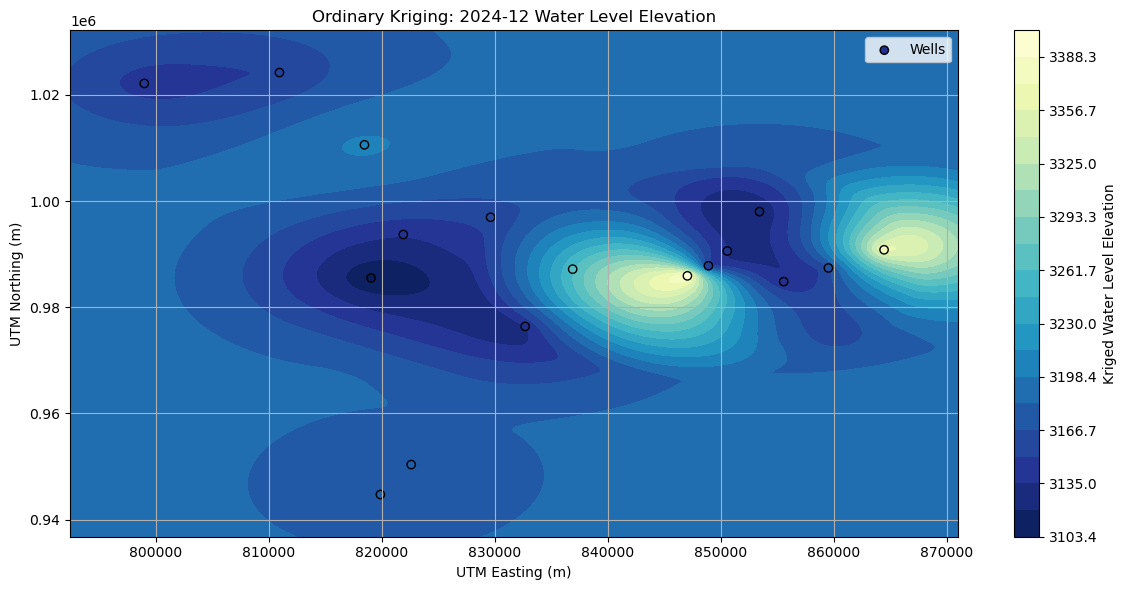

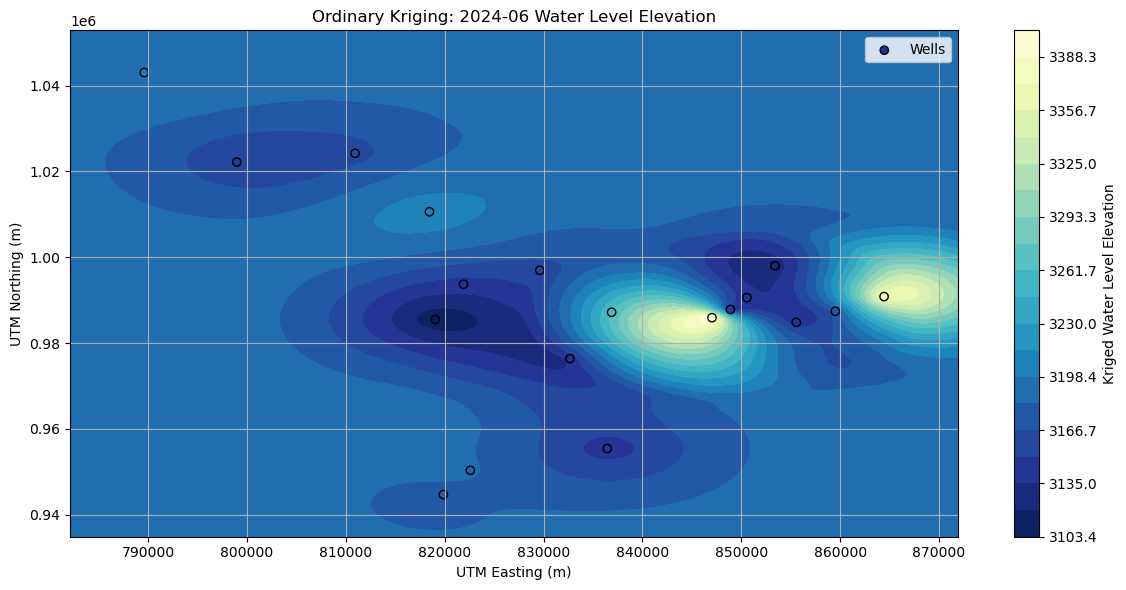

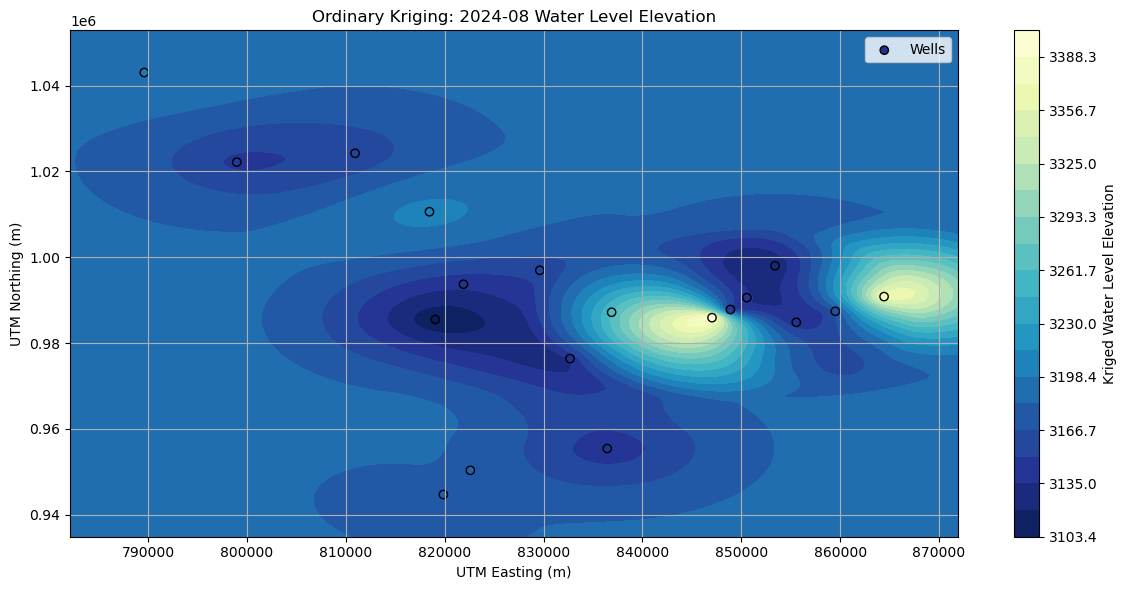

In [215]:

def plot_kriging(wells_month_df, year, month):
    """
    Filters data, performs Kriging interpolation, and plots a contour map for a specific month and year.
    """
    # 1. Filter data for the given year and month
    x, y, z = filter_kriging(wells_month_df, year, month)

    # 2. Define grid range with a larger buffer (10% instead of 5%)
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    x_buffer = 0.10 * x_range  # Increase buffer to 10%
    y_buffer = 0.10 * y_range  # Increase buffer to 10%

    # Create grid with a higher resolution (300 instead of 200)
    grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 300)  # Increase grid resolution
    grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 300)  # Increase grid resolution
    grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

    #Normalize data
    scaler = MinMaxScaler()
    z_normalized = scaler.fit_transform(z.reshape(-1, 1)).flatten()  # Normalize the data
    # 3. Kriging setup
    OK = OrdinaryKriging(
        x, y, z,
        variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential'
        variogram_parameters={'range': 20000, 'sill': 3000, 'nugget': 1},
        verbose=False,
        enable_plotting=False,
        coordinates_type='euclidean',  # UTM coords are cartesian
    )

    # 4. Perform kriging over the grid
    z_pred, z_var = OK.execute('grid', grid_x, grid_y)
    
    # 5. Define contour levels based on the global min and max range
    levels = np.linspace(z_total_min, z_total_max, 20)  # Define 20 levels for better contrast

    # 6. Define custom color map (using color brewer)
    colors = [
        "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
        "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
    ][::-1]
    custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)

    # 7. Plot the results with consistent dynamic contour levels
    plt.figure(figsize=(12, 6))
    contour = plt.contourf(grid_x, grid_y, z_pred, levels=levels, cmap=custom_cmap)
    plt.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')
    plt.colorbar(contour, label='Kriged Water Level Elevation')
    plt.xlabel('UTM Easting (m)')
    plt.ylabel('UTM Northing (m)')
    plt.title(f'Ordinary Kriging: {year}-{month:02d} Water Level Elevation')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Now plot for different months with the same global z scaling
plot_kriging(wells_month_df, 2024, 12)
plot_kriging(wells_month_df, 2024, 6)
plot_kriging(wells_month_df, 2024, 8)

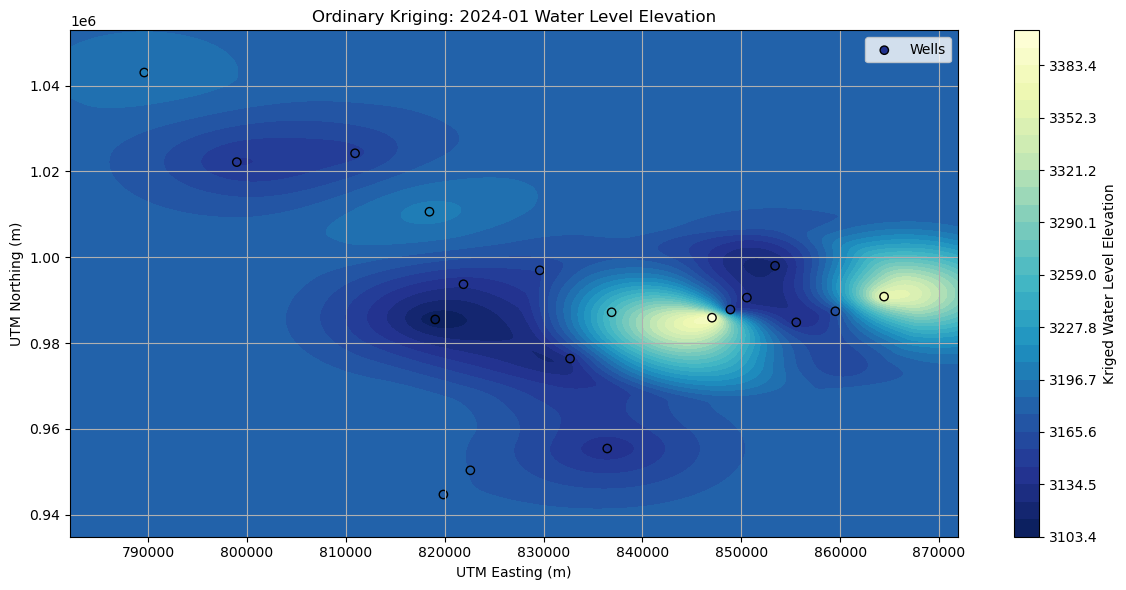

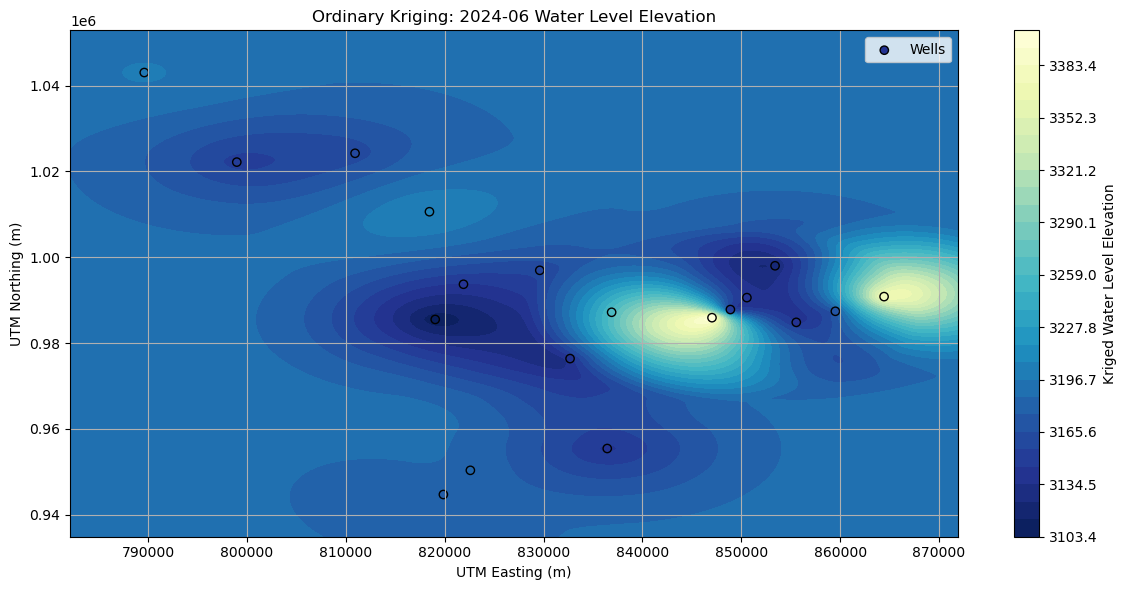

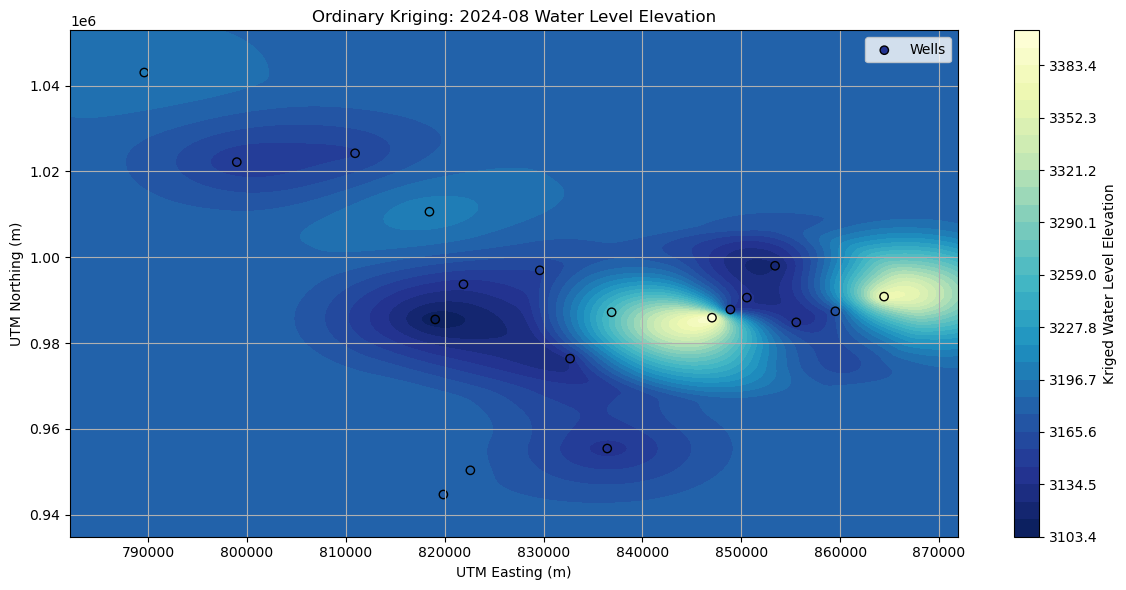

In [216]:
from scipy import interpolate
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from pykrige.ok import OrdinaryKriging
from matplotlib.colors import LinearSegmentedColormap

def plot_kriging(wells_month_df, year, month):
    """
    Filters data, performs Kriging interpolation, and plots a contour map for a specific month and year.
    """
    # 1. Filter data for the given year and month
    x, y, z = filter_kriging(wells_month_df, year, month)

    # 2. Define grid range with a larger buffer (10% instead of 5%)
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    x_buffer = 0.10 * x_range  # Increase buffer to 10%
    y_buffer = 0.10 * y_range  # Increase buffer to 10%

    # Create grid with a higher resolution (300 instead of 200)
    grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 500)  # Increase grid resolution
    grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 500)  # Increase grid resolution
    grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

    # Normalize data for Kriging (you can skip this if you want to work with raw data)
    scaler = MinMaxScaler()
    z_normalized = scaler.fit_transform(z.reshape(-1, 1)).flatten()  # Normalize the data

    # 3. Kriging setup
    OK = OrdinaryKriging(
        x, y, z,
        variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential'
        variogram_parameters={'range': 20000, 'sill': 3000, 'nugget': 1},
        verbose=False,
        enable_plotting=False,
        coordinates_type='euclidean',  # UTM coords are cartesian
    )

    # 4. Perform kriging over the grid
    z_pred, z_var = OK.execute('grid', grid_x, grid_y)
    
    # Check for NaN values in z_pred (Kriging predictions)
    if np.any(np.isnan(z_pred)):
        print("Warning: NaN values found in Kriging predictions.")
        
        # Use griddata to interpolate NaN values using surrounding data points
        z_pred_filled = interpolate.griddata(
            (x, y), z, (grid_x_mesh, grid_y_mesh), method='cubic', fill_value=np.nanmean(z)
        )
        z_pred = z_pred_filled

    # 5. Define contour levels based on the global min and max range (from data scale)
    levels = np.linspace(z_total_min, z_total_max, 30)  # Define 30 levels for better contrast

    # 6. Define custom color map (using color brewer)
    colors = [
        "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
        "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
    ][::-1]
    custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)

    # 7. Plot the results with consistent dynamic contour levels
    plt.figure(figsize=(12, 6))
    contour = plt.contourf(grid_x, grid_y, z_pred, levels=levels, cmap=custom_cmap)
    plt.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')
    plt.colorbar(contour, label='Kriged Water Level Elevation')
    plt.xlabel('UTM Easting (m)')
    plt.ylabel('UTM Northing (m)')
    plt.title(f'Ordinary Kriging: {year}-{month:02d} Water Level Elevation')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Now plot for different months with the same global z scaling
plot_kriging(wells_month_df, 2024, 1)
plot_kriging(wells_month_df, 2024, 6)
plot_kriging(wells_month_df, 2024, 8)

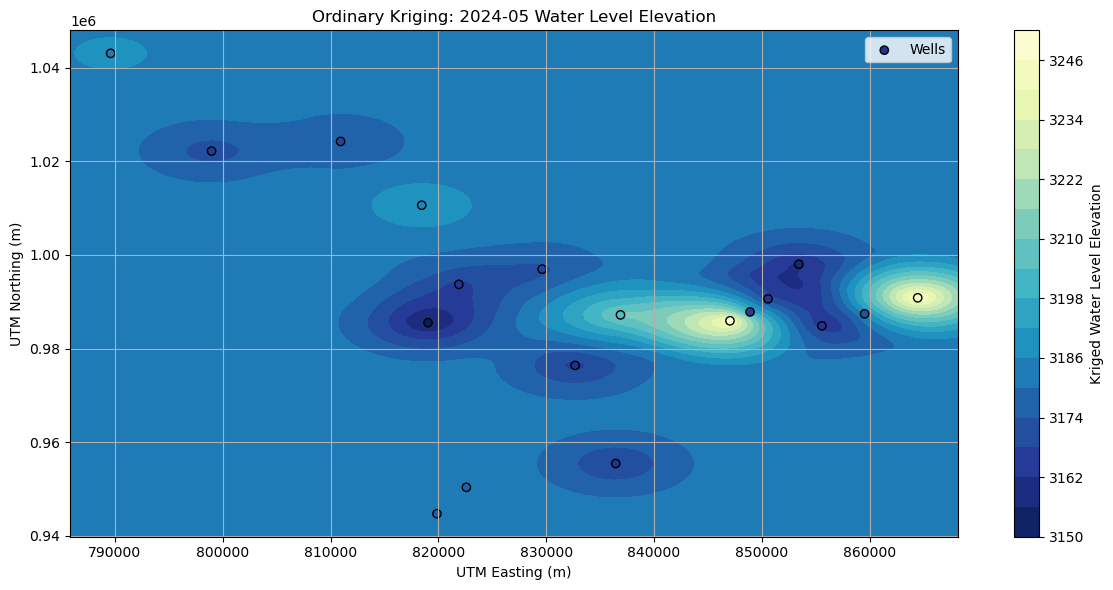

In [217]:
def plot_kriging(wells_month_df, year, month):
    """
    Filters data, performs Kriging interpolation, and plots a contour map for a specific month and year.
    """
    # 1. Filter data for the given year and month
    x, y, z = filter_kriging(wells_month_df, year, month)

    # 2. Define grid range with a 5% buffer
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    x_buffer = 0.05 * x_range
    y_buffer = 0.05 * y_range

    # Create grid with buffer
    grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 200)
    grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 200)
    grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

    # 3. Kriging setup
    OK = OrdinaryKriging(
        x, y, z,
        variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential'
        verbose=False,
        enable_plotting=False,
        coordinates_type='euclidean',  # UTM coords are cartesian
    )

    # 4. Perform kriging over the grid
    z_pred, z_var = OK.execute('grid', grid_x, grid_y)

    # 5. Define custom color map (using color brewer)
    colors = [
        "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
        "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
    ][::-1]
    custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)

    # 6. Plot the results
    plt.figure(figsize=(12, 6))
    contour = plt.contourf(grid_x, grid_y, z_pred, levels=15, cmap=custom_cmap)
    plt.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')
    plt.colorbar(contour, label='Kriged Water Level Elevation')
    plt.xlabel('UTM Easting (m)')
    plt.ylabel('UTM Northing (m)')
    plt.title(f'Ordinary Kriging: {year}-{month:02d} Water Level Elevation')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_kriging(wells_month_df, 2024, 5)

In [218]:
print(wells_month_df.loc['2024-04'].head())  # Data for January 2024
print(wells_month_df.loc['2024-02'].head())  # Data for February 2024

                                    well  water_level_elevation_mean  \
year_month                                                             
2024-04        WQD_21_Blaine_Crosby_Deep                 3136.589392   
2024-04     WQD_09_Great_Western_Shallow                 3138.115674   
2024-04         WQD_25_Hellgate_Monument                 3177.968652   
2024-04            WQD_32_South_Bancroft                 3133.650537   
2024-04             WQD_24_Vantage_Villa                 3164.994265   

            latitude   longitude        x_utm        y_utm  
year_month                                                  
2024-04     8.895416 -107.767663  855561.3125  984841.7500  
2024-04     8.978086 -108.072744  821899.8750  993713.5625  
2024-04     8.586457 -108.069494  822596.4375  950365.0625  
2024-04     8.820877 -107.976075  832681.7500  976396.0625  
2024-04     8.918350 -107.731559  859514.4375  987416.1875  
                                    well  water_level_elevation_mean

In [219]:
x_range = x.max() - x.min()
y_range = y.max() - y.min()
x_buffer = 0.05 * x_range
y_buffer = 0.05 * y_range

# 2. Create Grid with buffer
grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 200)
grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 200)
grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

# 3. Kriging setup
OK = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential 'spherical
    verbose=False,
    enable_plotting=False,
    coordinates_type='euclidean',  # UTM coords are cartesian                  # Small nugget effect can help in noisy data 
)

# 4. Perform kriging over the grid
z_pred, z_var = OK.execute('grid', grid_x, grid_y)

#Color brewer color palete
colors = [
    "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
    "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
][::-1]

custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)
# 5. Plot the results
plt.figure(figsize=(12, 6))
contour = plt.contourf(grid_x, grid_y, z_pred, levels=15, cmap=custom_cmap)
plt.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')
plt.colorbar(contour, label='Kriged Water Level (Jan 2024)')
plt.xlabel('UTM Easting (m)')
plt.ylabel('UTM Northing (m)')
plt.title('Ordinary Kriging: January 2024 Water Level Elevation')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 58311 but size of corresponding boolean axis is 57630

In [ ]:
# 1. Extract x (Easting), y (Northing), and z (water level)
x = january_df['x_utm'].values
y = january_df['y_utm'].values
z = january_df['water_level_elevation_mean'].values

# Compute buffer (5% of range) to expa d view window
x_range = x.max() - x.min()
y_range = y.max() - y.min()
x_buffer = 0.05 * x_range
y_buffer = 0.05 * y_range

# 2. Create Grid with buffer
grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 200)
grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 200)
grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

# 3. Kriging setup
OK = OrdinaryKriging(
    x, y, z,
    variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential 'spherical
    verbose=False,
    enable_plotting=False,
    coordinates_type='euclidean',  # UTM coords are cartesian                  # Small nugget effect can help in noisy data 
)

# 4. Perform kriging over the grid
z_pred, z_var = OK.execute('grid', grid_x, grid_y)

#Color brewer color palete
colors = [
    "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
    "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
][::-1]

custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)
# 5. Plot the results
plt.figure(figsize=(12, 6))
contour = plt.contourf(grid_x, grid_y, z_pred, levels=15, cmap=custom_cmap)
plt.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')
plt.colorbar(contour, label='Kriged Water Level (Jan 2024)')
plt.xlabel('UTM Easting (m)')
plt.ylabel('UTM Northing (m)')
plt.title('Ordinary Kriging: January 2024 Water Level Elevation')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
wells_month_df

In [424]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def plot_z_values_comparison(wells_month_df, year):
    """
    Plots the z-values (water level elevations) across months for a given year,
    with each well's data shown as a line and colored by well ID.
    """
    months = range(1, 13)  # For all months (1 to 12)

    # Generate a colormap based on the number of unique well IDs
    well_ids = wells_month_df['well'].unique()
    colormap = cm.get_cmap('tab20', len(well_ids))  # Using a colormap with a sufficient number of distinct colors
    well_colors = {well_id: colormap(i) for i, well_id in enumerate(well_ids)}  # Mapping each well to a color
    
    plt.figure(figsize=(12, 6))
    
    # Loop over each well and plot the water level elevations across months
    for well_id in well_ids:
        # Filter for the given well ID and year
        well_data = wells_month_df[(wells_month_df['well'] == well_id) & (wells_month_df.index.year == year)]
        
        # Extract z-values for each month
        z_values = []
        for month in months:
            monthly_data = well_data[well_data.index.month == month]
            z_values.append(monthly_data['water_level_elevation_mean'].values[0] if not monthly_data.empty else np.nan)
        
        # Plot the z-values across months for this well, colored by well ID
        plt.plot(months, z_values, label=f'Well {well_id}', color=well_colors[well_id], marker='o', linestyle='-', markersize=5)
    
    # Customize plot
    plt.xlabel('Month')
    plt.ylabel('Water Level Elevation (z)')
    plt.title(f'Water Level Elevation (z) Across Months for {year}')
    plt.xticks(months)  # Set x-axis ticks to be the month numbers (1 to 12)
    plt.legend(title="Well ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# Plot z-values across months for 2024
plot_z_values_comparison(wells_month_df, 2024)

/var/folders/7m/7135t6f90pz1cpw89nf4_hch0000gn/T/ipykernel_43178/2152162383.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', len(well_ids))  # Using a colormap with a sufficient number of distinct colors


AttributeError: 'RangeIndex' object has no attribute 'year'

<Figure size 1200x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def plot_relative_changes(wells_month_df, year):
    """
    Plots the relative change in water level elevations across months for each well in the given year.
    The change is calculated as the difference from the first month of data for each well.
    """
    months = range(1, 13)  # For all months (1 to 12)

    # Generate a colormap based on the number of unique well IDs
    well_ids = wells_month_df['well'].unique()
    colormap = cm.get_cmap('tab20', len(well_ids))  # Using a colormap with a sufficient number of distinct colors
    well_colors = {well_id: colormap(i) for i, well_id in enumerate(well_ids)}  # Mapping each well to a color
    
    plt.figure(figsize=(12, 6))
    
    # Loop over each well and plot the relative change in water level elevations across months
    for well_id in well_ids:
        # Filter for the given well ID and year
        well_data = wells_month_df[(wells_month_df['well'] == well_id) & (wells_month_df.index.year == year)]
        
        # Extract z-values for each month
        z_values = []
        for month in months:
            monthly_data = well_data[well_data.index.month == month]
            z_values.append(monthly_data['water_level_elevation_mean'].values[0] if not monthly_data.empty else np.nan)
        
        # Compute relative change: subtract the first month's value from all subsequent months
        initial_value = z_values[0]  # First month's value
        relative_changes = np.array(z_values) - initial_value  # Subtract the initial value to get the relative change
        
        # Plot the relative change across months for this well, colored by well ID
        plt.plot(months, relative_changes, label=f'Well {well_id}', color=well_colors[well_id], marker='o', linestyle='-', markersize=5)
    
    # Customize plot
    plt.xlabel('Month')
    plt.ylabel('Relative Change in Water Level Elevation (z)')
    plt.title(f'Relative Change in Water Level Elevation (z) Across Months for {year}')
    plt.xticks(months)  # Set x-axis ticks to be the month numbers (1 to 12)
    plt.legend(title="Well ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# Plot relative changes in water level elevations for 2024
plot_relative_changes(wells_month_df, 2024)

In [ ]:
def add_normalized_changes(wells_month_df):
    """
    Adds a column of normalized relative changes in water level elevation to the wells_month_df DataFrame.
    The change is calculated as the difference from the first month of data for each well, and then normalized.
    """
    # Initialize the scaler for normalization
    scaler = MinMaxScaler()

    # Initialize a list to hold the normalized changes for each well
    normalized_changes = []

    # Loop through each well to calculate relative changes and normalize
    for well_id in wells_month_df['well'].unique():
        well_data = wells_month_df[wells_month_df['well'] == well_id]

        # Extract z-values for each month
        z_values = []
        for month in range(1, 13):
            monthly_data = well_data[well_data.index.month == month]
            if not monthly_data.empty:
                z_values.append(monthly_data['water_level_elevation_mean'].values[0])
            else:
                z_values.append(np.nan)

        # Compute relative change: subtract the first month's value from all subsequent months
        initial_value = z_values[0]  # First month's value
        relative_changes = np.array(z_values) - initial_value  # Subtract the initial value to get the relative change
        
        # Normalize the relative changes (to scale between 0 and 1)
        normalized_values = scaler.fit_transform(relative_changes.reshape(-1, 1)).flatten()

        # Add the normalized values to the DataFrame
        for month, norm_change in zip(range(1, 13), normalized_values):
            wells_month_df.loc[(wells_month_df['well'] == well_id) & (wells_month_df.index.month == month), 'normalized_relative_change'] = norm_change
    
    return wells_month_df

# Add normalized relative changes to the DataFrame
wells_month_df = add_normalized_changes(wells_month_df)



In [395]:
wells_month_df

,well,water_level_elevation_mean,latitude,longitude,x_utm,y_utm,y_utm_corrected,short_well_name,Well_ID,geometry
0,WQD_21_Blaine_Crosby_Deep,3139.501571,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
1,WQD_21_Blaine_Crosby_Deep,3139.118008,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
2,WQD_21_Blaine_Crosby_Deep,3138.174362,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
3,WQD_21_Blaine_Crosby_Deep,3136.953026,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
4,WQD_21_Blaine_Crosby_Deep,3135.881301,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
...,...,...,...,...,...,...,...,...,...,...
335,WQD_30_McCormick_Park,3144.489047,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
336,WQD_30_McCormick_Park,3143.564822,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
337,WQD_30_McCormick_Park,3142.413894,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
338,WQD_30_McCormick_Park,3141.643056,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)


In [375]:
import geopandas as gpd
import pandas as pd
import requests
from shapely.geometry import Point
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.geometry import box

In [358]:
# 1. Load the Streams shapefile (assuming it's in the same folder)
streams_gdf = gpd.read_file('rivers/riverslakes/Streams24K_NamedOnly.shp')
aquifer_gdf = gpd.read_file('Aquifers/Shapefile/PrincipalAquifers_MT.shp')
# 2. Check the CRS of the streams data
print("Streams CRS:", streams_gdf.crs)
print("Aquifer CRS:", aquifer_gdf.crs)
# 3. Ensure streams_gdf CRS matches well_shp's CRS (assuming well_shp's CRS is EPSG:4326)
# If it's not, reproject the streams data to match well_shp (EPSG:4326)
streams_gdf = streams_gdf.to_crs(epsg=4326)
aquifer_gdf = aquifer_gdf.to_crs(epsg=4326)
# 4. Check the CRS after reprojecting (should match wells)
print("Streams CRS after reprojecting:", streams_gdf.crs)
print("Aquifer CRS after reprojecting:", aquifer_gdf.crs)

/opt/anaconda3/envs/dataprocess/lib/python3.13/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Streams CRS: COMPD_CS["NAD83(2011) / Montana + NAVD88 height",PROJCS["NAD83(2011) / Montana",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",44.25],PARAMETER["central_meridian",-109.5],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",45],PARAMETER["false_easting",600000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6514"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5703"]]]
Aquifer CRS: EPSG:32100
Streams CRS af

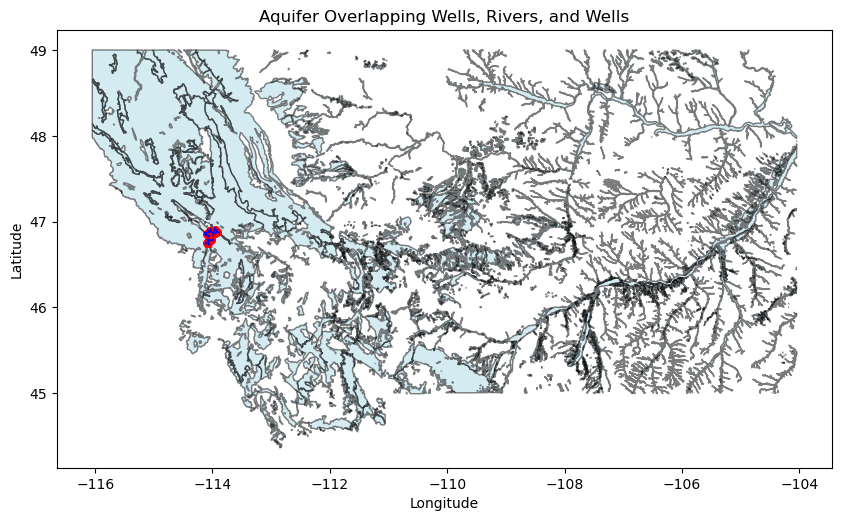

In [369]:
# 1. Reproject aquifers if needed (to match wells CRS)
aquifer_gdf = aquifer_gdf.to_crs(wells_latlon.crs)

# 2. Spatial join: find aquifers that wells intersect
aquifer_wells_join = gpd.sjoin(aquifer_gdf, wells_latlon, how="inner", predicate="contains")

# 3. Drop duplicates if multiple wells are on the same aquifer
aquifer_selected = aquifer_gdf[aquifer_gdf.index.isin(aquifer_wells_join.index)]

# 2. Now clip the aquifer polygon to that buffer
aquifer_clipped = gpd.clip(aquifer_selected, wells_buffer_projected)

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clipped aquifer
aquifer_clipped.plot(ax=ax, facecolor='lightblue', edgecolor='black', alpha=0.5)

# Plot wells
wells_latlon.plot(ax=ax, color='red', markersize=30)

# Plot rivers
rivers_clipped.plot(ax=ax, color='blue', linewidth=1)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clipped Aquifer, Wells, and Rivers')
plt.show()

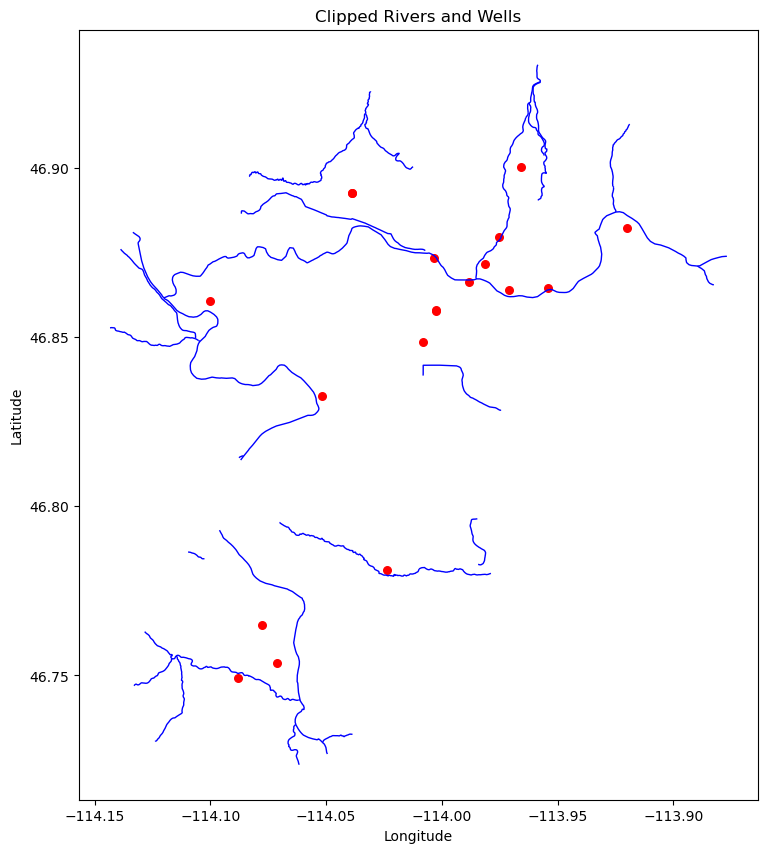

In [360]:
# 1. Reproject the wells to a projected CRS (e.g., EPSG:3857 for Web Mercator)
wells_latlon_projected = wells_latlon.to_crs(epsg=3857)

# 2. Increase the buffer distance (e.g., 5000 meters for a larger region around the wells)
buffer_distance = 5000  # Increase this distance (e.g., 5000 meters)
wells_buffer_projected = wells_latlon_projected.buffer(buffer_distance)

# 3. Reproject the buffer back to EPSG:4326 (lat/lon)
wells_buffer = wells_buffer_projected.to_crs(epsg=4326)

# 4. Clip the rivers to the new, larger well buffer (boundary)
rivers_clipped = gpd.clip(streams_gdf, wells_buffer)

# 5. Plot the clipped rivers along with the wells
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clipped rivers (in blue)
rivers_clipped.plot(ax=ax, color='blue', linewidth=1)


# Plot wells (in red)
wells_latlon.plot(ax=ax, color='red', markersize=30)

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clipped Rivers and Wells')

# Show the plot
plt.show()


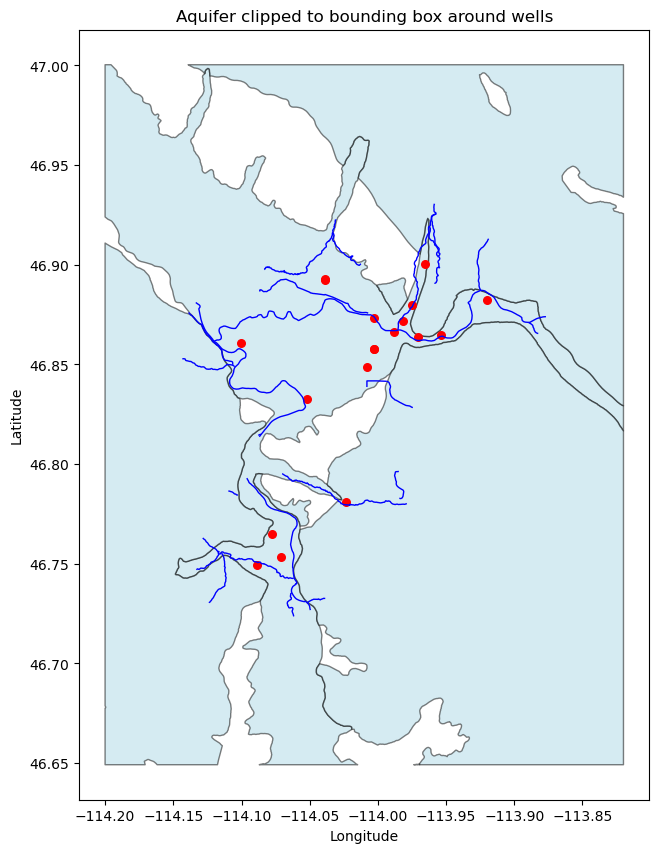

In [377]:
# 1. Build a bounding box around the wells
padding = 0.1  # degrees, adjust this
minx, miny, maxx, maxy = wells_latlon.total_bounds
bbox = gpd.GeoDataFrame(geometry=[box(minx - padding, miny - padding, maxx + padding, maxy + padding)], crs=wells_latlon.crs)

# 2. Clip aquifer to the bounding box
aquifer_clipped = gpd.clip(aquifer_selected, bbox)

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 10))
aquifer_clipped.plot(ax=ax, facecolor='lightblue', edgecolor='black', alpha=0.5)
wells_latlon.plot(ax=ax, color='red', markersize=30)
rivers_clipped.plot(ax=ax, color='blue', linewidth=1)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Aquifer clipped to bounding box around wells')
plt.show()



EPSG:4326
EPSG:4326


In [400]:
from dbfread import DBF

# 1. Load and project wells & rivers
wells_shp = gpd.read_file("WQD_Monitoring_Wells.shp")


# 2. Reproject the shapefile to geographic (lat/lon)
wells_latlon = wells_shp.to_crs(epsg=4326)


dbf_file = 'WQD_Monitoring_Wells.dbf'
table = DBF(dbf_file)

# Convert to a pandas DataFrame for easier inspection
dbf_df = pd.DataFrame(iter(table))

#COl names
wells_month_df['short_well_name'] = wells_month_df['well'].str.split('_').str[:2].str.join('_')

wells_month_df['Well_ID'] = wells_month_df['short_well_name'].str.replace('_', '-')

# 2. Merge the wells_latlon GeoDataFrame with wells_month_df on Well_ID
wells_month_df = wells_month_df.merge(wells_latlon[['Well_ID', 'geometry']], left_on='Well_ID', right_on='Well_ID', how='left')

# Extract the short_well_name from wells_month_df
wells_to_keep = wells_month_df['short_well_name'].unique()

# Replace underscores with hyphens in wells_to_keep
wells_to_keep_fixed = [w.replace('_', '-') for w in wells_to_keep]

# Now filter wells_shp using the original Well_ID column
filtered_wells_shp = wells_shp[wells_shp['Well_ID'].isin(wells_to_keep_fixed)]

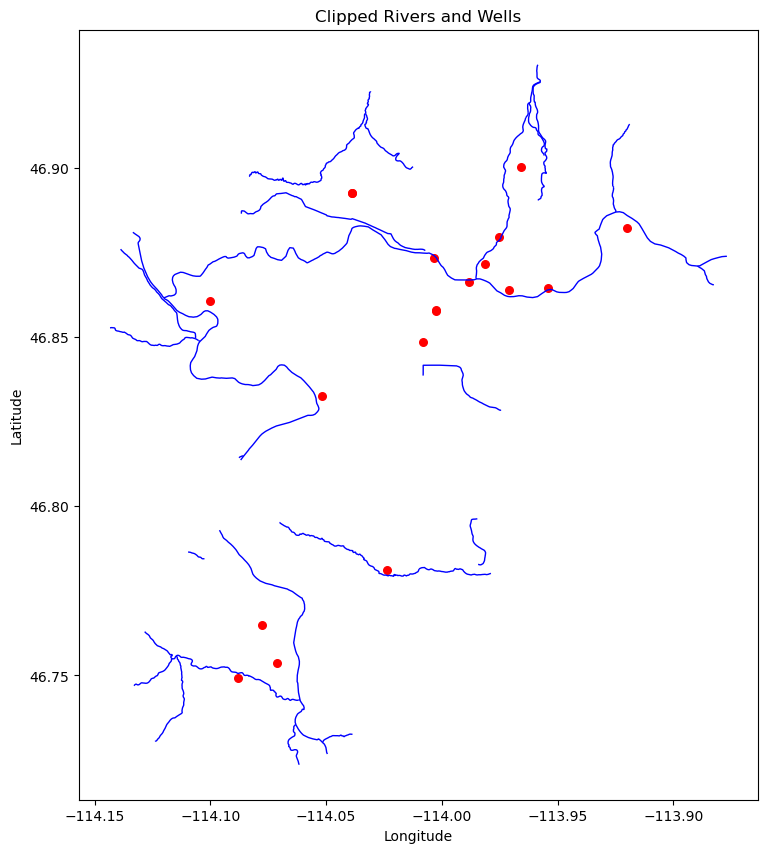

In [354]:
filtered_wells_shp
wells_latlon = filtered_wells_shp.to_crs(epsg=4326)

# 1. Reproject the wells to a projected CRS (e.g., EPSG:3857 for Web Mercator)
wells_latlon_projected = wells_latlon.to_crs(epsg=3857)

# 2. Increase the buffer distance (e.g., 5000 meters for a larger region around the wells)
buffer_distance = 5000  # Increase this distance (e.g., 5000 meters)
wells_buffer_projected = wells_latlon_projected.buffer(buffer_distance)

# 3. Reproject the buffer back to EPSG:4326 (lat/lon)
wells_buffer = wells_buffer_projected.to_crs(epsg=4326)

# 4. Clip the rivers to the new, larger well buffer (boundary)
rivers_clipped = gpd.clip(streams_gdf, wells_buffer)

# 5. Plot the clipped rivers along with the wells
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clipped rivers (in blue)
rivers_clipped.plot(ax=ax, color='blue', linewidth=1)

# Plot wells (in red)
wells_latlon.plot(ax=ax, color='red', markersize=30)

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clipped Rivers and Wells')

# Show the plot
plt.show()


In [356]:
# 1. Reproject the wells to a projected CRS (e.g., EPSG:3857 for Web Mercator)


In [341]:
# Compare the bounds (or plot them)
print("Wells bounds:", wells_latlon.total_bounds)
print("Rivers bounds:", rivers_gdf.total_bounds)


Wells bounds: [-114.27260528   46.74918452 -113.91995216   47.03152408]
Rivers bounds: [-117.63263753   48.36422538 -111.62342396   50.21193369]


In [295]:
wells_shp
from pyproj import Transformer

# 1. Define the transformer: from EPSG:3857 → EPSG:4326
transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

# 2. Your Web Mercator coordinates
x_mercator = -12720768.231
y_mercator = 5947083.253

# 3. Perform the inverse transformation
lon, lat = transformer.transform(x_mercator, y_mercator)



Longitude: -114.272605, Latitude: 47.030680


In [382]:
# 1. Replace underscores with hyphens in short_well_name of wells_month_df
wells_month_df['Well_ID'] = wells_month_df['short_well_name'].str.replace('_', '-')

# 2. Merge the wells_latlon GeoDataFrame with wells_month_df on Well_ID
wells_month_df = wells_month_df.merge(wells_latlon[['Well_ID', 'geometry']], left_on='Well_ID', right_on='Well_ID', how='left')


In [383]:
wells_month_df

,well,water_level_elevation_mean,latitude,longitude,x_utm,y_utm,y_utm_corrected,short_well_name,Well_ID,geometry
0,WQD_21_Blaine_Crosby_Deep,3139.501571,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
1,WQD_21_Blaine_Crosby_Deep,3139.118008,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
2,WQD_21_Blaine_Crosby_Deep,3138.174362,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
3,WQD_21_Blaine_Crosby_Deep,3136.953026,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
4,WQD_21_Blaine_Crosby_Deep,3135.881301,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
...,...,...,...,...,...,...,...,...,...,...
335,WQD_30_McCormick_Park,3144.489047,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
336,WQD_30_McCormick_Park,3143.564822,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
337,WQD_30_McCormick_Park,3142.413894,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
338,WQD_30_McCormick_Park,3141.643056,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)


In [425]:
def plot_kriging_with_rivers(wells_month_df, year, month, rivers_clipped):
    """
    Filters data, performs Kriging interpolation, and plots a contour map for a specific month and year.
    Includes clipped rivers overlay.
    """
    # 1. Convert the index to string and filter data for the given year and month
    wells_month_filtered = wells_month_df[wells_month_df.index.astype(str).str.contains(f"{year}-{month:02d}")]
    
    # Check if filtered data is empty
    if wells_month_filtered.empty:
        print(f"No data available for {year}-{month:02d}. Skipping Kriging and plotting.")
        return  # Skip plotting if no data is available

    # 2. Ensure the 'geometry' column is a valid GeoSeries by converting it to a GeoDataFrame
    if not isinstance(wells_month_filtered, gpd.GeoDataFrame):
        wells_month_filtered = gpd.GeoDataFrame(wells_month_filtered, geometry=gpd.GeoSeries.from_wkt(wells_month_filtered['geometry']))

    # 3. Extract x, y from geometry column (ensure it's in UTM coordinates)
    wells_month_filtered['x'] = wells_month_filtered.geometry.x
    wells_month_filtered['y'] = wells_month_filtered.geometry.y

    x = wells_month_filtered['x'].values
    y = wells_month_filtered['y'].values
    z = wells_month_filtered['water_level_elevation_mean'].values  # Ensure correct column for z-values

    # 4. Define grid range with a larger buffer (10% instead of 5%)
    x_range = x.max() - x.min()
    y_range = y.max() - y.min()
    x_buffer = 0.10 * x_range  # Increase buffer to 10%
    y_buffer = 0.10 * y_range  # Increase buffer to 10%

    # Create grid with a higher resolution (300 instead of 200)
    grid_x = np.linspace(x.min() - x_buffer, x.max() + x_buffer, 300)  # Increase grid resolution
    grid_y = np.linspace(y.min() - y_buffer, y.max() + y_buffer, 300)  # Increase grid resolution
    grid_x_mesh, grid_y_mesh = np.meshgrid(grid_x, grid_y)

    # Normalize data
    scaler = MinMaxScaler()
    z_normalized = scaler.fit_transform(z.reshape(-1, 1)).flatten()  # Normalize the data

    # 5. Kriging setup
    OK = OrdinaryKriging(
        x, y, z,
        variogram_model='spherical',  # or 'linear', 'gaussian', 'exponential'
        variogram_parameters={'range': 20000, 'sill': 3000, 'nugget': 1},
        verbose=False,
        enable_plotting=False,
        coordinates_type='euclidean',  # UTM coords are cartesian
    )

    # 6. Perform kriging over the grid
    z_pred, z_var = OK.execute('grid', grid_x, grid_y)

    # 7. Define contour levels based on the global min and max range
    z_total_min, z_total_max = z.min(), z.max()
    levels = np.linspace(z_total_min, z_total_max, 20)  # Define 20 levels for better contrast

    # 8. Define custom color map (using color brewer)
    colors = [
        "#ffffd9", "#edf8b1", "#c7e9b4", "#7fcdbb",
        "#41b6c4", "#1d91c0", "#225ea8", "#253494", "#081d58"
    ][::-1]
    custom_cmap = LinearSegmentedColormap.from_list("ylgnbu_custom", colors)

    # 9. Plot the results with consistent dynamic contour levels
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the Kriging contour map
    contour = ax.contourf(grid_x, grid_y, z_pred, levels=levels, cmap=custom_cmap)

    # Overlay the clipped rivers
    rivers_clipped.plot(ax=ax, color='blue', linewidth=1, alpha=0.7)

    # Scatter the wells on the plot
    ax.scatter(x, y, c=z, edgecolor='black', cmap=custom_cmap, label='Wells')

    # Add a colorbar
    plt.colorbar(contour, label='Kriged Water Level Elevation')

    # Label and title
    ax.set_xlabel('UTM Easting (m)')
    ax.set_ylabel('UTM Northing (m)')
    ax.set_title(f'Ordinary Kriging: {year}-{month:02d} Water Level Elevation')

    # Add a legend
    plt.legend()

    # Show the grid and plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Now use this to plot for different months
plot_kriging_with_rivers(wells_month_df, 2024, 12, rivers_clipped)
plot_kriging_with_rivers(wells_month_df, 2024, 6, rivers_clipped)
plot_kriging_with_rivers(wells_month_df, 2024, 8, rivers_clipped)

No data available for 2024-12. Skipping Kriging and plotting.
No data available for 2024-06. Skipping Kriging and plotting.
No data available for 2024-08. Skipping Kriging and plotting.


First few rows of the DataFrame:
                         well  water_level_elevation_mean  latitude  \
0  WQD_21_Blaine_Crosby_Deep                 3139.501571  8.895416   
1  WQD_21_Blaine_Crosby_Deep                 3139.118008  8.895416   
2  WQD_21_Blaine_Crosby_Deep                 3138.174362  8.895416   
3  WQD_21_Blaine_Crosby_Deep                 3136.953026  8.895416   
4  WQD_21_Blaine_Crosby_Deep                 3135.881301  8.895416   

    longitude        x_utm      y_utm  y_utm_corrected short_well_name  \
0 -107.767663  855561.3125  984841.75       4984841.75          WQD_21   
1 -107.767663  855561.3125  984841.75       4984841.75          WQD_21   
2 -107.767663  855561.3125  984841.75       4984841.75          WQD_21   
3 -107.767663  855561.3125  984841.75       4984841.75          WQD_21   
4 -107.767663  855561.3125  984841.75       4984841.75          WQD_21   

  Well_ID                     geometry  
0  WQD-21  POINT (-114.00258 46.85792)  
1  WQD-21  POINT (

In [393]:
 wells_month_df

,well,water_level_elevation_mean,latitude,longitude,x_utm,y_utm,y_utm_corrected,short_well_name,Well_ID,geometry
0,WQD_21_Blaine_Crosby_Deep,3139.501571,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
1,WQD_21_Blaine_Crosby_Deep,3139.118008,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
2,WQD_21_Blaine_Crosby_Deep,3138.174362,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
3,WQD_21_Blaine_Crosby_Deep,3136.953026,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
4,WQD_21_Blaine_Crosby_Deep,3135.881301,8.895416,-107.767663,855561.3125,9.848418e+05,4.984842e+06,WQD_21,WQD-21,POINT (-114.00258 46.85792)
...,...,...,...,...,...,...,...,...,...,...
335,WQD_30_McCormick_Park,3144.489047,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
336,WQD_30_McCormick_Park,3143.564822,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
337,WQD_30_McCormick_Park,3142.413894,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
338,WQD_30_McCormick_Park,3141.643056,9.236792,-108.279129,798972.0625,1.022172e+06,5.022172e+06,WQD_30,WQD-30,POINT (-114.00318 46.87348)
